## Import Library

In [3]:
import pickle
import pandas as pd
import random
import os
import datetime
import time
import numpy as np
from PIL import Image
from wordcloud import WordCloud, ImageColorGenerator
import matplotlib.pyplot as plt
import re
import string
import nltk
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import PorterStemmer
from collections import Counter
from tqdm import tqdm
import json
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    classification_report, 
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GridSearchCV
import seaborn as sns
tqdm.pandas()

In [4]:
nltk.download('stopwords')
stop_words_indonesian = set(stopwords.words('indonesian'))
stop_words_english = set(stopwords.words('english'))

uni_stopwords = stop_words_indonesian | stop_words_english

stemmer_id = StemmerFactory().create_stemmer()  # Bahasa Indonesia
stemmer_en = PorterStemmer()  # Bahasa Inggris

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
# Root Path Data
ROOT_DATA = 'data'
# Datasets Path
DATASET_PATH = os.path.join(ROOT_DATA, 'datasets')
# Utils Path
UTILS_PATH = os.path.join(ROOT_DATA, 'utils')
# Result Path
RESULTS_PATH = os.path.join(ROOT_DATA, 'results')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\fujir\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Preprocessing Data

In [5]:
data = pd.read_csv(os.path.join(DATASET_PATH, 'Data_Hasil_Scraping.csv'))
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19175 entries, 0 to 19174
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Review ID    19175 non-null  object
 1   Username     19175 non-null  object
 2   Rating       19175 non-null  int64 
 3   Review Text  19175 non-null  object
 4   Date         19175 non-null  object
dtypes: int64(1), object(4)
memory usage: 749.2+ KB


In [6]:
data.head(10)

,Review ID,Username,Rating,Review Text,Date
0,0655184a-1c99-47dd-b414-8dac6117e2dc,Fazhar Maulana,2,saldo belum masuk mohon di bantu 1.6jt saldo b...,2025-12-31 09:39:02
1,11427750-0653-4652-87a1-5d75b7ce5d46,olakun Sarvi,1,mohon di perbaiki attitude CS nya Yang bernama...,2025-12-31 07:27:45
2,cd88665b-8e76-41bb-9ba6-f0cc3b2350d0,Eky Vm,1,setiap isi paket lewat isaku slalu gagal dan s...,2025-12-30 18:02:36
3,b458280d-6abe-452d-904b-7ff86145cea1,Stanislaus william permadhi,1,"eror pada proses pengajuan akun full servis, C...",2025-12-30 10:06:14
4,d2f1c989-9a81-4bf5-89e5-d2068d80a0a2,Ahmad Sanusi,1,ini gimana isaku beli pulsa 100 ribu saldo udh...,2025-12-30 09:56:05
5,f200cfec-4b5c-4265-886b-0eec7f792ff5,Lyndha Olshop,1,"Minta update, m-mulu HBSin kuota.. otw hapus a...",2025-12-30 08:20:10
6,5ec7ed7d-75a2-47c3-a565-6641aa201092,Almatia Tumilo,5,sangat bagus,2025-12-29 21:27:57
7,46dbc6eb-89a8-4814-972a-22e64cb9276e,Wildan Hamdan,4,Saran untuk developer isaku: Sediakan cara Top...,2025-12-29 10:44:05
8,d16a4a5e-05c6-45a0-a1d5-9b1735900d06,Ferdy Ansyah,4,puas,2025-12-28 23:19:26
9,886ed0a9-24fd-413a-a5b6-fcace791f87e,Putri Sukaina,1,pembayaran berhasil tagihan belum terbayar par...,2025-12-28 23:11:50


In [7]:
df = pd.DataFrame(data[['Date', 'Username', 'Rating', 'Review Text']])
df.head(5)

,Date,Username,Rating,Review Text
0,2025-12-31 09:39:02,Fazhar Maulana,2,saldo belum masuk mohon di bantu 1.6jt saldo b...
1,2025-12-31 07:27:45,olakun Sarvi,1,mohon di perbaiki attitude CS nya Yang bernama...
2,2025-12-30 18:02:36,Eky Vm,1,setiap isi paket lewat isaku slalu gagal dan s...
3,2025-12-30 10:06:14,Stanislaus william permadhi,1,"eror pada proses pengajuan akun full servis, C..."
4,2025-12-30 09:56:05,Ahmad Sanusi,1,ini gimana isaku beli pulsa 100 ribu saldo udh...


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19175 entries, 0 to 19174
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         19175 non-null  object
 1   Username     19175 non-null  object
 2   Rating       19175 non-null  int64 
 3   Review Text  19175 non-null  object
dtypes: int64(1), object(3)
memory usage: 599.3+ KB


In [9]:
print("Jumlah data sebelum dedup", len(df))
df.drop_duplicates(subset = "Review Text", keep='first', inplace=True)
print("Jumlah data setelah dedup", len(df))

Jumlah data sebelum dedup 19175
Jumlah data setelah dedup 15350


## WordCloud Ketika Sebelum di Preprocessing

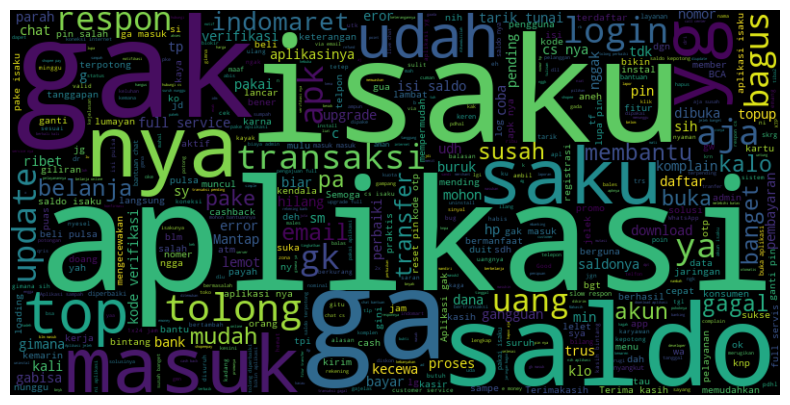

In [10]:
# Isi nilai NaN dengan string kosong ('')
df['Review Text'] = df['Review Text'].fillna('')

# penggabungan teks dari kolom 'content'
text = ' '.join(df['Review Text'].astype(str).tolist())

uni_stopwords.update(['https', 'co', 'RT', '...', 'amp'])

wc = WordCloud(stopwords=uni_stopwords, background_color="black", max_words=500, width=800, height=400)

wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

## menampilkan 10 kata teratas

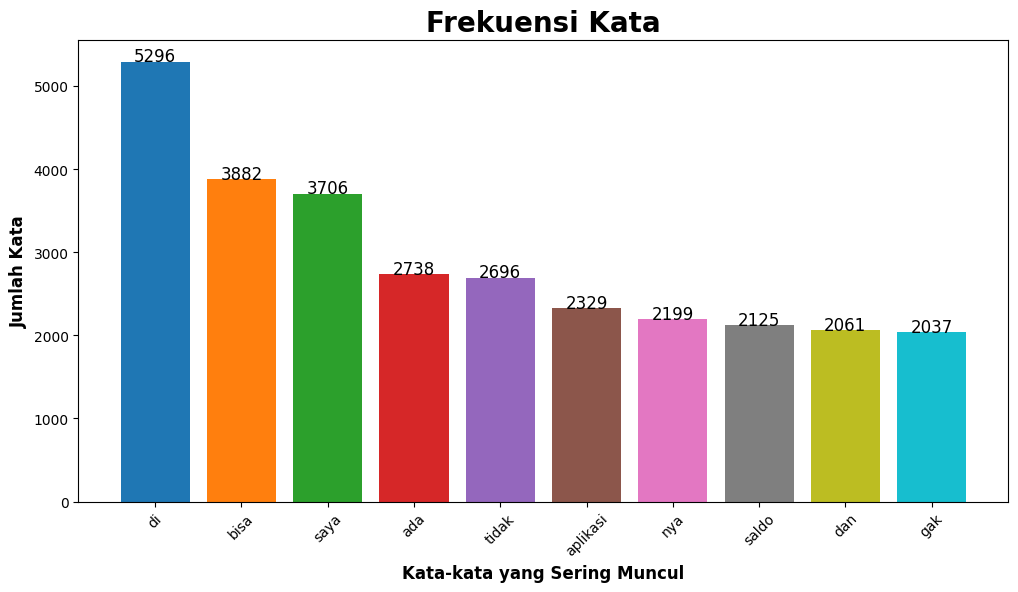

In [11]:
text = " ".join(df["Review Text"])

tokens = text.split()
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)

word, count = zip(*top_words)  

# warna
colors = plt.cm.tab10(range(len(word)))

plt.figure(figsize=(12, 6))
bars = plt.bar(word, count, color=colors)

plt.xlabel("Kata-kata yang Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=20, fontweight='bold')

plt.xticks(rotation=45)

# label angka di atas bar
for bar, num in zip(bars, count):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        num + 1,
        str(num),
        fontsize=12,
        color='black',
        ha='center'
    )

plt.show()

## A. Cleaning Data

In [12]:
pip install nltk

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [13]:
# Hapus URL
def remove_URL(text):
    if text is not None and isinstance(text, str):
        url = re.compile(r'https?://\S+|www\.\S+')
        return url.sub(r'', text)
    else:
        return text

# Hapus HTML
def remove_html(text):
    if text is not None and isinstance(text, str):
        html = re.compile(r'<.*?>')
        return html.sub(r'', text)
    else:
        return text

def normalize_elongated_words(text):
    """
    Normalisasi kata yang diperpanjang
    'bagussss' -> 'bagus'
    'mantaaaap' -> 'mantap'
    """
    # Hapus repeated characters (lebih dari 2)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    return text

def case_folding(text):
    if isinstance(text, str):
        lowercase_text = text.lower()
        return lowercase_text
    else:
        return text

# Hapus Emoji
def remove_emoji(text):
    if text is not None and isinstance(text, str):
        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"    # Emoticons
            u"\U0001F300-\U0001F5FF"    # Symbols & Pictographs
            u"\U0001F680-\U0001F6FF"    # Transport & Map Symbols
            u"\U0001F700-\U0001F77F"    # Alchemical Symbols
            u"\U0001F780-\U0001F7FF"    # Geometric Shapes Extended
            u"\U0001F800-\U0001F8FF"    # Supplemental Arrows-c
            u"\U0001F900-\U0001F9FF"    # Supplemental Symbols & Pictographs
            u"\U0001FA00-\U0001FA6F"    # Chess Symbols
            u"\U0001FA70-\U0001FAFF"    # Symbols & Pictographs Extended-A
            u"\U0001F004-\U0001F0CF"    # Additional Emoticons
            u"\U0001F1E0-\U0001F1FF"    # flags
        "]+", flags=re.UNICODE)
        return emoji_pattern.sub(r'', text)
    else:
        return text

# Hapus Simbol
def remove_symbols(text):
    if text is not None and isinstance(text, str):
        return re.sub(r'[^\w\s]', ' ', text)
    return text

# Hapus Angka
def remove_numbers(text):
    if text is not None and isinstance(text, str):
        text = re.sub(r'\d', ' ', text)
    return text

In [14]:
def text_cleaning(text):
    if pd.isna(text) or text == "":
        return ""
    
    # Hapus Emoji
    text = remove_emoji(text)
    
    # Casefolding
    text = case_folding(text)
    
    # Normalize elongated words (mantappppp -> mantapp)
    text = normalize_elongated_words(text)
    
    # Hapus URL
    text = remove_URL(text)
    
    # Hapus Symbol
    text = remove_symbols(text)
    
    # Hapus Angka
    text = remove_numbers(text)
    
    # Hapus extra whitespace
    text = ' '.join(text.split())
    
    return text

df['cleaned_text'] = df['Review Text'].progress_apply(
    lambda text: text_cleaning(text) 
)

100%|██████████| 15350/15350 [00:00<00:00, 35003.67it/s]


In [15]:
# Hanya berlaku untuk perintah di dalam 'with' block
with pd.option_context('display.max_colwidth', None):
    display(df[['Review Text', 'cleaned_text']].sample(10))

,Review Text,cleaned_text
5035,saldoku gak masuk..hubungi customer gak acc..,saldoku gak masuk hubungi customer gak acc
2177,Transaksi transfer gk msuk giliran d chat dan Emil no respon sampe saat ini,transaksi transfer gk msuk giliran d chat dan emil no respon sampe saat ini
12154,"Customer service nya tidak ada tanggapan sama sekali, 3 hari tidak ada jawaban. No pin tidak bisa direset, gagal terus. Uang dideposit kan tidak bisa d pakai. Rugi...",customer service nya tidak ada tanggapan sama sekali hari tidak ada jawaban no pin tidak bisa direset gagal terus uang dideposit kan tidak bisa d pakai rugi
19110,I love it...thats it,i love it thats it
4504,"Aplikasi AMPAS, BUKA LOADING, BANYAK ERORNYA. BENTAR² MINTA UPDATE BUKANNYA MAKIN BAGUS MALAH MAKIN AMPASSSSS 👎🏿💩 KALAU BISA NGASIH NILAI 0 GUA KASIH NOL INI APLIKASI. 👎🏿💩💩💩💩 BAYANGIN PAS MAU BELANJA UDAH DEPAN KASIR MAU BAYAR BUKA APLIKASI EROR GABISA KEBUKA, KAN ASUUUUU 👎🏿💩",aplikasi ampas buka loading banyak erornya bentar² minta update bukannya makin bagus malah makin ampass kalau bisa ngasih nilai gua kasih nol ini aplikasi bayangin pas mau belanja udah depan kasir mau bayar buka aplikasi eror gabisa kebuka kan asuu
5613,Aplikasinya lemot gak setelah update Saya harap lebih di optimalkan kembali aplikasi nya supaya konsumen lebih nyaman menggunakan aplikasi isaku ketika belanja,aplikasinya lemot gak setelah update saya harap lebih di optimalkan kembali aplikasi nya supaya konsumen lebih nyaman menggunakan aplikasi isaku ketika belanja
12715,"Maaf lagi dikasih bintang satu karena lemot saat akses kontak buat isi pulsa,,mohon diperbaiki 🙏",maaf lagi dikasih bintang satu karena lemot saat akses kontak buat isi pulsa mohon diperbaiki
10548,Masih belum di FU jg komplain.. Uang itu oooyyyy jgn lamaaaa,masih belum di fu jg komplain uang itu ooyy jgn lamaa
15228,Bnyk casback i like it,bnyk casback i like it
6577,Yth developer tolong apa bisa dibantu untuk akun isaku yang nomornya hilang sehingga tidak bisa verifikasi akun di hp baru,yth developer tolong apa bisa dibantu untuk akun isaku yang nomornya hilang sehingga tidak bisa verifikasi akun di hp baru


## B. Normalization

In [49]:
pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [16]:
# load kamus dari excel
kamus_data = pd.read_excel(os.path.join(UTILS_PATH, 'kamuskatabaku.xlsx'))

kamus_tidak_baku = dict(zip(
    kamus_data['tidak_baku'],
    kamus_data['kata_baku']
))

In [17]:
#load slang
slang_dict = {}

with open(os.path.join(UTILS_PATH, 'combined_slang_words.txt'), 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split('\t')  # kalau error ganti ','

        if len(parts) == 2:
            slang_dict[parts[0]] = parts[1]

with open(os.path.join(UTILS_PATH, 'extended_slang_typo.json'), 'r', encoding='utf-8') as f:
    extended_slang = json.load(f)
    slang_dict.update(extended_slang)

kamus_tidak_baku.update(slang_dict)

In [18]:
#load kamus dari csv
colloquial = pd.read_csv(os.path.join(DATASET_PATH, 'colloquial-indonesian-lexicon.csv'))

colloquial_dict = dict(zip(
    colloquial.iloc[:,0],
    colloquial.iloc[:,1]
))

kamus_tidak_baku.update(colloquial_dict)

In [19]:
# Lower key-value kamus tidak baku
kamus_tidak_baku = {
    str(k).lower(): str(v).lower()
    for k, v in kamus_tidak_baku.items()
}

In [20]:
value_counts = Counter(kamus_tidak_baku.values())
duplicate_values = {k: v for k, v in value_counts.items() if v > 1}

print(f"Total unique values (formal words): {len(value_counts)}")
print(f"Formal words yang digunakan > 1 slang: {len(duplicate_values)}")

if duplicate_values:
    print("\nTop 10 formal words dengan slang terbanyak:")
    for i, (formal, count) in enumerate(sorted(duplicate_values.items(), 
                                               key=lambda x: x[1], 
                                               reverse=True)[:10], 1):
        slang_list = [k for k, v in kamus_tidak_baku.items() if v == formal]
        print(f"   {i}. '{formal}' ← {count} slang words")
        print(f"      Contoh: {', '.join(slang_list[:5])}")

Total unique values (formal words): 2095
Formal words yang digunakan > 1 slang: 724

Top 10 formal words dengan slang terbanyak:
   1. 'banget' ← 89 slang words
      Contoh: bgt, bangett, bngt, bangettt, bingitsss
   2. 'cantik' ← 51 slang words
      Contoh: syantik, cantiik, ntik, cantikkk, cntik
   3. 'ya' ← 44 slang words
      Contoh: yaa, yah, yeee, yha, yaaa
   4. 'amin' ← 34 slang words
      Contoh: aminn, amiin, aamiin, amiiinn, amiiiin
   5. 'yuk' ← 26 slang words
      Contoh: yokkk, yu, yuuuk, yuwkkk, yuuuuk
   6. 'saja' ← 25 slang words
      Contoh: aja, aj, aza, ajhh, sja
   7. 'keren' ← 24 slang words
      Contoh: kerrrrennnn, kereeeeennnn, kereeen, kereenn, kereen
   8. 'kangen' ← 24 slang words
      Contoh: kangenn, kgn, kangem, kangeeeeeeeeennnnnnnn, kangennnnnmnnnnnnnnnnnnnnnnn
   9. 'sih' ← 22 slang words
      Contoh: sii, seehh, sie, sihhh, sey
   10. 'enggak' ← 22 slang words
      Contoh: ngga, gk, ga, gak, ngak


## Proses Normalisasi Kata

In [21]:
def normalize_slang(text):
    """
    Normalisasi slang words dengan:
    1. Cek langsung di kamus
    2. Normalisasi huruf berulang (3+ → 2)
    3. Normalisasi agresif (2+ → 1)
    
    TIDAK LOG unknown words - hanya normalisasi
    """
    if not isinstance(text, str):
        return ''
    
    # Pre-compiled regex
    pattern_2 = re.compile(r'(.)\1{2,}')  # 3+ → 2
    pattern_1 = re.compile(r'(.)\1+')     # 2+ → 1
    
    words = text.split()
    hasil = []
    
    for word in words:
        # 1. Cek langsung di kamus
        if word in kamus_tidak_baku:
            hasil.append(kamus_tidak_baku[word])
            continue
        
        # 2. Normalisasi 3+ → 2, lalu cek kamus
        normalized_2 = pattern_2.sub(r'\1\1', word)
        if normalized_2 in kamus_tidak_baku:
            hasil.append(kamus_tidak_baku[normalized_2])
            continue
        
        # 3. Normalisasi 2+ → 1, lalu cek kamus
        normalized_1 = pattern_1.sub(r'\1', word)
        if normalized_1 in kamus_tidak_baku:
            hasil.append(kamus_tidak_baku[normalized_1])
            continue
        
        # 4. Tidak ditemukan - gunakan hasil normalisasi atau original
        final_word = normalized_2 if normalized_2 != word else word
        hasil.append(final_word)

    return ' '.join(hasil)

def analyze_unknown_words(df, column='cleaned_text', sample_size=10000):
    """
    Analisis kata-kata yang tidak ada di kamus SEBELUM preprocessing lengkap
    Hanya untuk analisis, bukan untuk preprocessing
    """
    print("Menganalisis unknown words...")
    
    unknown_words = []
    pattern_2 = re.compile(r'(.)\1{2,}')
    pattern_1 = re.compile(r'(.)\1+')
    
    # Sample data untuk analisis
    sample_texts = df[column].sample(min(sample_size, len(df)), random_state=42)
    
    for text in sample_texts:
        if not isinstance(text, str):
            continue
        
        # Preprocessing minimal
        text = text.lower()
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'@\w+', '', text)
        text = re.sub(r'#\w+', '', text)
        text = re.sub(r'[^\w\s]', '', text)
        
        words = text.split()
        
        for word in words:
            # Skip kata yang terlalu pendek atau terlalu panjang
            if len(word) < 3 or len(word) > 20:
                continue
            
            # Skip angka
            if word.isdigit():
                continue
            
            # Cek apakah ada di kamus
            if word in kamus_tidak_baku:
                continue
            
            # Cek setelah normalisasi
            normalized_2 = pattern_2.sub(r'\1\1', word)
            if normalized_2 in kamus_tidak_baku:
                continue
            
            normalized_1 = pattern_1.sub(r'\1', word)
            if normalized_1 in kamus_tidak_baku:
                continue
            
            # Hanya log kata yang kemungkinan slang
            # (mengandung huruf berulang atau pendek)
            if (len(word) <= 6 or 
                bool(re.search(r'(.)\1+', word)) or
                word not in uni_stopwords):
                unknown_words.append(word)
    
    # Hitung frekuensi
    word_counts = Counter(unknown_words)
    
    print(f"\nTotal unknown words: {len(unknown_words)}")
    print(f"Unique unknown words: {len(word_counts)}")
    print("\nTop 50 unknown words:")
    print("-" * 60)
    
    for i, (word, count) in enumerate(word_counts.most_common(50), 1):
        print(f"{i:3}. {word:30} → {count:5}x")
    
    return word_counts

In [22]:
# Jika ingin analisis unknown words, jalankan fungsi terpisah
unknown_counts = analyze_unknown_words(df, column='Review Text', sample_size=1000)
unknown_res_path = os.path.join(RESULTS_PATH, 'unknown_words_analysis.txt')
# Simpan hasil analisis
with open(unknown_res_path, 'w', encoding='utf-8') as f:
    f.write("# Unknown Words Analysis (Sample: 1000 reviews)\n")
    f.write("#" + "="*77 + "\n\n")
    for word, count in unknown_counts.most_common():
        f.write(f"{word}\t{count}\n")

print("✅ Analisis disimpan ke: unknown_words_analysis.txt")

Menganalisis unknown words...

Total unknown words: 10831
Unique unknown words: 2158

Top 50 unknown words:
------------------------------------------------------------
  1. bisa                           →   307x
  2. saya                           →   291x
  3. aplikasi                       →   244x
  4. isaku                          →   201x
  5. ada                            →   178x
  6. ini                            →   177x
  7. tidak                          →   175x
  8. saldo                          →   162x
  9. mau                            →   140x
 10. dan                            →   124x
 11. sudah                          →   121x
 12. masuk                          →   115x
 13. sangat                         →    91x
 14. tapi                           →    89x
 15. tolong                         →    84x
 16. login                          →    81x
 17. lagi                           →    78x
 18. yang                           →    69x
 19. kenapa          

In [23]:
#penerapan ke data
df['normalized_text'] = df['cleaned_text'].apply(normalize_slang)

In [24]:
# Hasil Normalisasi
normalized_df = df[['Review Text','cleaned_text','normalized_text']]
normalized_df.to_csv(os.path.join(RESULTS_PATH, 'normalized_result.csv'))
normalized_df.sample(10)

,Review Text,cleaned_text,normalized_text
7962,Tolong apk isaku saya lagi eror,tolong apk isaku saya lagi eror,tolong aplikasi isaku saya lagi galat
685,"sangat bagus,,, tpi kenapa tiap mau tranfer yg...",sangat bagus tpi kenapa tiap mau tranfer yg ke...,sangat bagus tapi kenapa tiap mau tranfer yang...
1192,Makin lama aplikasinya makin buruk setiap mau ...,makin lama aplikasinya makin buruk setiap mau ...,makin lama aplikasinya makin buruk setiap mau ...
14954,"Ok, bisa membantu",ok bisa membantu,ok bisa membantu
10583,"Aplikasi jelek,koneksi servernya parah,pas lag...",aplikasi jelek koneksi servernya parah pas lag...,aplikasi jelek koneksi servernya parah pas lag...
219,tolong diperbaiki lagi ya isi saldo e-toll bel...,tolong diperbaiki lagi ya isi saldo e toll bel...,tolong diperbaiki lagi ya isi saldo e toll bel...
5132,Isaku tolong di bantu udh Komplen via chat ban...,isaku tolong di bantu udh komplen via chat ban...,isaku tolong di bantu sudah komplen via chat b...
13322,app pelit admin bank ny dimakan sendiri.nyesal...,app pelit admin bank ny dimakan sendiri nyesal...,apa pelit admin bank nya dimakan sendiri nyesa...
13666,tolong update isaku saya ya ke versi 2.0.0,tolong update isaku saya ya ke versi,tolong update isaku saya ya ke versi
14706,penting untuk jaman sekarang,penting untuk jaman sekarang,penting untuk jaman sekarang


In [25]:
normalized_df.to_csv('tes.csv')

## C. Tokenization

In [26]:
def tokenize_text(text):
    tokens = text.split()
    return tokens

df['tokenized_text'] = df['normalized_text'].apply(tokenize_text)

df.head(5)

,Date,Username,Rating,Review Text,cleaned_text,normalized_text,tokenized_text
0,2025-12-31 09:39:02,Fazhar Maulana,2,saldo belum masuk mohon di bantu 1.6jt saldo b...,saldo belum masuk mohon di bantu jt saldo belu...,saldo belum masuk mohon di bantu juta saldo be...,"[saldo, belum, masuk, mohon, di, bantu, juta, ..."
1,2025-12-31 07:27:45,olakun Sarvi,1,mohon di perbaiki attitude CS nya Yang bernama...,mohon di perbaiki attitude cs nya yang bernama...,mohon di perbaiki attitude customer service ya...,"[mohon, di, perbaiki, attitude, customer, serv..."
2,2025-12-30 18:02:36,Eky Vm,1,setiap isi paket lewat isaku slalu gagal dan s...,setiap isi paket lewat isaku slalu gagal dan s...,setiap isi paket lewat isaku selalu gagal dan ...,"[setiap, isi, paket, lewat, isaku, selalu, gag..."
3,2025-12-30 10:06:14,Stanislaus william permadhi,1,"eror pada proses pengajuan akun full servis, C...",eror pada proses pengajuan akun full servis cu...,galat pada proses pengajuan akun full servis c...,"[galat, pada, proses, pengajuan, akun, full, s..."
4,2025-12-30 09:56:05,Ahmad Sanusi,1,ini gimana isaku beli pulsa 100 ribu saldo udh...,ini gimana isaku beli pulsa ribu saldo udh kep...,ini bagaimana isaku beli pulsa ribu saldo suda...,"[ini, bagaimana, isaku, beli, pulsa, ribu, sal..."


## D. Stopword Removal

In [27]:
def remove_stopwords(text):
    return [word for word in text if word not in uni_stopwords]

df['stopword_text'] = df['tokenized_text'].apply(lambda x: remove_stopwords(x))

df.sample(10)

,Date,Username,Rating,Review Text,cleaned_text,normalized_text,tokenized_text,stopword_text
6917,2022-12-01 09:14:16,D-IRF 30,1,Top up saldo tidak masuk ..aplikasi gak jelas,top up saldo tidak masuk aplikasi gak jelas,top up saldo tidak masuk aplikasi enggak jelas,"[top, up, saldo, tidak, masuk, aplikasi, engga...","[top, saldo, masuk, aplikasi]"
1453,2024-11-30 08:42:28,Santo Loing,1,Transfer ke bank udah 3 hari ga msuk masuk ke ...,transfer ke bank udah hari ga msuk masuk ke ba...,transfer ke bank sudah hari enggak masuk masuk...,"[transfer, ke, bank, sudah, hari, enggak, masu...","[transfer, bank, masuk, masuk, bank, tuju, sal..."
11368,2021-08-19 12:22:56,Rachmad Wahyudi,5,Juzz,juzz,juzz,[juzz],[juzz]
8718,2022-05-24 07:13:17,Sun H,2,Kenapa diupdate yg terbaru aplikasi gak bisa d...,kenapa diupdate yg terbaru aplikasi gak bisa d...,kenapa diupdate yang terbaru aplikasi enggak b...,"[kenapa, diupdate, yang, terbaru, aplikasi, en...","[diupdate, terbaru, aplikasi, dibuka, stuck, l..."
910,2025-05-28 16:25:27,Muhammad Affani,1,"utk transaksi Qris sangat susah, dan sering ti...",utk transaksi qris sangat susah dan sering tid...,untuk transaksi qris sangat susah dan sering t...,"[untuk, transaksi, qris, sangat, susah, dan, s...","[transaksi, qris, susah, dibuka, ditanggal, ga..."
16334,2020-06-23 11:53:09,Oki Kriss,4,"Harusnya bintangnya sampai 5, tapi saya sangat...",harusnya bintangnya sampai tapi saya sangat ti...,harusnya bintangnya sampai tapi saya sangat ti...,"[harusnya, bintangnya, sampai, tapi, saya, san...","[bintangnya, nyaman, notifikasi, saku, isaku, ..."
11961,2021-08-06 10:07:15,WendiKS official,5,Maaf ya semua karena saldo tiba tiba terpotong...,maaf ya semua karena saldo tiba tiba terpotong...,maaf ya semua karena saldo tiba tiba terpotong...,"[maaf, ya, semua, karena, saldo, tiba, tiba, t...","[maaf, ya, saldo, terpotong, habis, hack, pulung]"
4068,2023-07-01 23:40:28,Sincang kw,1,"Knpa saldoku tinggal 17 ribu aku isi 100 ribu,...",knpa saldoku tinggal ribu aku isi ribu ada isi...,kenapa saldoku tinggal ribu aku isi ribu ada i...,"[kenapa, saldoku, tinggal, ribu, aku, isi, rib...","[saldoku, tinggal, ribu, isi, ribu, isi, saldo..."
16113,2020-07-27 16:56:27,Junius Hutapea,5,Makin banyak diskon,makin banyak diskon,makin banyak diskon,"[makin, banyak, diskon]",[diskon]
19041,2020-01-08 15:39:51,Pengguna Google,5,"Memudahkan di saat tidak membawa uang, bisa ja...",memudahkan di saat tidak membawa uang bisa jad...,memudahkan di cepat tidak membawa uang bisa ja...,"[memudahkan, di, cepat, tidak, membawa, uang, ...","[memudahkan, cepat, membawa, uang, alternatif,..."


## E. Stemming

In [28]:
def stem_text(text):
    """
    Hanya stem kata yang panjangnya > 4 karakter
    Kata pendek biasanya sudah root word
    """
    result = []
    for word in text:
        if len(word) <= 4:
            # Kata pendek, skip stemming
            result.append(word)
        else:
            # Coba Indonesian stemmer dulu
            stemmed_id = stemmer_id.stem(word)
            
            # Jika tidak berubah, coba English stemmer
            if stemmed_id == word:
                result.append(stemmer_en.stem(word))
            else:
                result.append(stemmed_id)
    
    return result

df['stemmed_text']  = df['stopword_text'].progress_apply(lambda x: ' '.join(stem_text(x)))
df.sample(10)

100%|██████████| 15350/15350 [10:51<00:00, 23.56it/s]


,Date,Username,Rating,Review Text,cleaned_text,normalized_text,tokenized_text,stopword_text,stemmed_text
6964,2022-11-29 18:53:02,benk seven,1,"kembalikan uang saya ,saya isi 200 ribu dari t...",kembalikan uang saya saya isi ribu dari tgl sa...,kembalikan uang saya saya isi ribu dari tangga...,"[kembalikan, uang, saya, saya, isi, ribu, dari...","[kembalikan, uang, isi, ribu, tanggal, masuk]",kembali uang isi ribu tanggal masuk
4260,2023-05-26 11:07:00,Ika Anggraini,1,Ada masalah. Isinya cuma suruh nunggu nunggu d...,ada masalah isinya cuma suruh nunggu nunggu da...,ada masalah isinya cuma suruh menunggu menungg...,"[ada, masalah, isinya, cuma, suruh, menunggu, ...","[isinya, suruh, menunggu, menunggu, menunggu, ...",isi suruh tunggu tunggu tunggu email balas
9939,2021-12-04 12:54:45,Miggih Sora Putra,1,"Lemot om,, update jngan makin lemot dong, masa...",lemot om update jngan makin lemot dong masa ma...,lambat om update jangan makin lambat dong masa...,"[lambat, om, update, jangan, makin, lambat, do...","[lambat, om, update, lambat, transfer, bangkin...",lambat om updat lambat transfer bangk bayar tu...
1159,2025-03-09 13:13:45,hendra kurniawan,1,"Jangan install isaku, applikasi jelek banget. ...",jangan install isaku applikasi jelek banget up...,jangan install isaku aplikasi jelek banget upg...,"[jangan, install, isaku, aplikasi, jelek, bang...","[install, isaku, aplikasi, jelek, banget, upgr...",instal isa aplikasi jelek banget upgrad akun j...
14077,2020-12-14 07:33:41,Dona Febriani,3,"Cara komplain i saku cemana ya admin, soal nya...",cara komplain i saku cemana ya admin soal nya ...,cara komplain i saku cemana ya admin soal ya t...,"[cara, komplain, i, saku, cemana, ya, admin, s...","[komplain, saku, cemana, ya, admin, ya, teman,...",komplain saku cemana ya admin ya teman trnsfer...
4709,2023-03-28 01:10:44,Tr suganda,2,Banyak eror nya makin ga beres lemot pembaruan...,banyak eror nya makin ga beres lemot pembaruan...,banyak galat ya makin enggak beres lambat pemb...,"[banyak, galat, ya, makin, enggak, beres, lamb...","[galat, ya, beres, lambat, pembaruan]",galat ya bere lambat baru
12883,2021-04-09 20:07:51,nur khalifah,5,Ini kenapa says buka appnya keluar keluar Teru...,ini kenapa says buka appnya keluar keluar teru...,ini kenapa says buka aplikasinya keluar keluar...,"[ini, kenapa, says, buka, aplikasinya, keluar,...","[says, buka, aplikasinya, ya]",says buka aplikasi ya
4262,2023-05-26 00:36:17,Aldrian Eka Putra,1,APLIKASI BUTA!!!! SAYA KOMPLAIN KE EMAIL RESMI...,aplikasi buta saya komplain ke email resmi dar...,aplikasi buta saya komplain ke email resmi dar...,"[aplikasi, buta, saya, komplain, ke, email, re...","[aplikasi, buta, komplain, email, resmi, tangg...",aplikasi buta komplain email resmi tanggal mei...
13919,2021-01-07 16:37:35,Muhammad ranggi Agam salafi,1,tolong dong top up gaem ada yg bisa 10juta don...,tolong dong top up gaem ada yg bisa juta dong ...,tolong dong top up gaem ada yang bisa juta don...,"[tolong, dong, top, up, gaem, ada, yang, bisa,...","[tolong, top, gaem, juta, tolang, tambahkan, i...",tolong top gaem juta tolang tambah isakuku nab...
10525,2021-10-27 19:19:28,santi dewi@gmail.con purwanti,5,Sangat membantu sekali 👍,sangat membantu sekali,sangat membantu sekali,"[sangat, membantu, sekali]",[membantu],bantu


In [29]:
df.to_csv(os.path.join(RESULTS_PATH, 'Hasil_Preprocessing_Data.csv'), encoding='utf-8', index=False)

## Wordcloud Setelah Preprocessing 

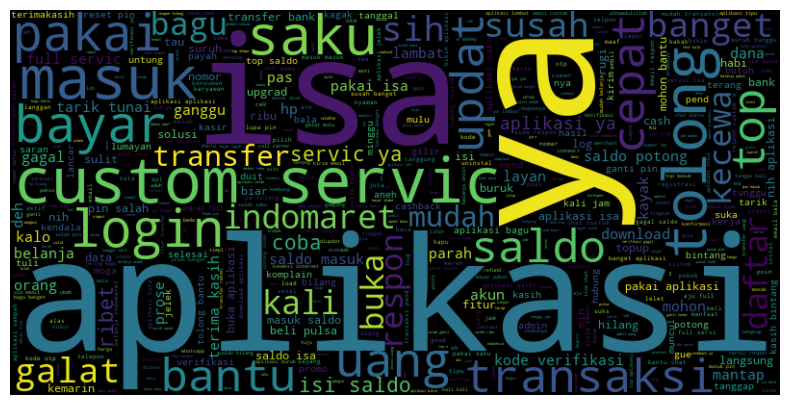

In [30]:
# penggabungan teks dari kolom 'content'
text = ' '.join(df['stemmed_text'].astype(str).tolist())

wc = WordCloud(stopwords=uni_stopwords, background_color="black", max_words=500, width=800, height=400)

wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

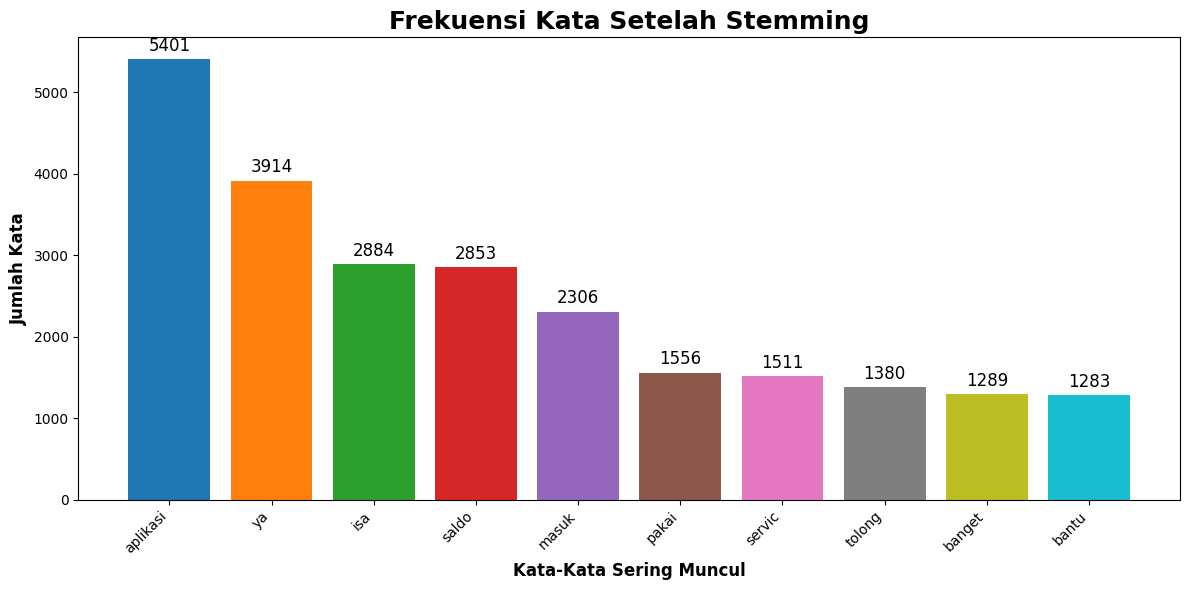

In [31]:
# Gabungkan semua teks dari kolom stemmed_text
text = " ".join(df["stemmed_text"].astype(str))

# Tokenisasi dan hitung frekuensi
tokens = text.split()
word_counts = Counter(tokens)
top_words = word_counts.most_common(10)
word, count = zip(*top_words)

# Definisi palet warna
colors = plt.cm.tab10(range(len(word)))

# Buat visualisasi
plt.figure(figsize=(12, 6))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata Setelah Stemming", fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Penambahan angka di atas setiap bar
for bar, num in zip(bars, count):
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        num + max(count) * 0.01,  # Offset dinamis berdasarkan nilai max
        str(num), 
        fontsize=12, 
        color='black', 
        ha='center',
        va='bottom'
    )

plt.show()


## F. Labeling

In [32]:
data = pd.read_csv(os.path.join(RESULTS_PATH, 'Hasil_Preprocessing_Data.csv'))
data.head(10)

,Date,Username,Rating,Review Text,cleaned_text,normalized_text,tokenized_text,stopword_text,stemmed_text
0,2025-12-31 09:39:02,Fazhar Maulana,2,saldo belum masuk mohon di bantu 1.6jt saldo b...,saldo belum masuk mohon di bantu jt saldo belu...,saldo belum masuk mohon di bantu juta saldo be...,"['saldo', 'belum', 'masuk', 'mohon', 'di', 'ba...","['saldo', 'masuk', 'mohon', 'bantu', 'juta', '...",saldo masuk mohon bantu juta saldo masuk email...
1,2025-12-31 07:27:45,olakun Sarvi,1,mohon di perbaiki attitude CS nya Yang bernama...,mohon di perbaiki attitude cs nya yang bernama...,mohon di perbaiki attitude customer service ya...,"['mohon', 'di', 'perbaiki', 'attitude', 'custo...","['mohon', 'perbaiki', 'attitude', 'customer', ...",mohon baik attitud custom servic ya nama andri...
2,2025-12-30 18:02:36,Eky Vm,1,setiap isi paket lewat isaku slalu gagal dan s...,setiap isi paket lewat isaku slalu gagal dan s...,setiap isi paket lewat isaku selalu gagal dan ...,"['setiap', 'isi', 'paket', 'lewat', 'isaku', '...","['isi', 'paket', 'isaku', 'gagal', 'cepat', 'd...",isi paket isa gagal cepat lapor respon
3,2025-12-30 10:06:14,Stanislaus william permadhi,1,"eror pada proses pengajuan akun full servis, C...",eror pada proses pengajuan akun full servis cu...,galat pada proses pengajuan akun full servis c...,"['galat', 'pada', 'proses', 'pengajuan', 'akun...","['galat', 'proses', 'pengajuan', 'akun', 'full...",galat prose aju akun full servi custom servic ...
4,2025-12-30 09:56:05,Ahmad Sanusi,1,ini gimana isaku beli pulsa 100 ribu saldo udh...,ini gimana isaku beli pulsa ribu saldo udh kep...,ini bagaimana isaku beli pulsa ribu saldo suda...,"['ini', 'bagaimana', 'isaku', 'beli', 'pulsa',...","['isaku', 'beli', 'pulsa', 'ribu', 'saldo', 't...",isa beli pulsa ribu saldo potong pulsa masuk
5,2025-12-30 08:20:10,Lyndha Olshop,1,"Minta update, m-mulu HBSin kuota.. otw hapus a...",minta update m mulu hbsin kuota otw hapus atuh,meminta update sama mulu habis kuota otw hapus...,"['meminta', 'update', 'sama', 'mulu', 'habis',...","['update', 'mulu', 'habis', 'kuota', 'otw', 'h...",updat mulu habi kuota otw hapu atuh
6,2025-12-29 21:27:57,Almatia Tumilo,5,sangat bagus,sangat bagus,sangat bagus,"['sangat', 'bagus']",['bagus'],bagu
7,2025-12-29 10:44:05,Wildan Hamdan,4,Saran untuk developer isaku: Sediakan cara Top...,saran untuk developer isaku sediakan cara top ...,saran untuk developer isaku sediakan cara top ...,"['saran', 'untuk', 'developer', 'isaku', 'sedi...","['saran', 'developer', 'isaku', 'sediakan', 't...",saran develop isa sedia top saku metod bi fast...
8,2025-12-28 23:19:26,Ferdy Ansyah,4,puas,puas,puas,['puas'],['puas'],puas
9,2025-12-28 23:11:50,Putri Sukaina,1,pembayaran berhasil tagihan belum terbayar par...,pembayaran berhasil tagihan belum terbayar par...,pembayaran berhasil tagihan belum terbayar par...,"['pembayaran', 'berhasil', 'tagihan', 'belum',...","['pembayaran', 'berhasil', 'tagihan', 'terbaya...",bayar hasil tagih bayar parah komplain susah b...


In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15350 entries, 0 to 15349
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Date             15350 non-null  object
 1   Username         15350 non-null  object
 2   Rating           15350 non-null  int64 
 3   Review Text      15350 non-null  object
 4   cleaned_text     15265 non-null  object
 5   normalized_text  15265 non-null  object
 6   tokenized_text   15350 non-null  object
 7   stopword_text    15350 non-null  object
 8   stemmed_text     15182 non-null  object
dtypes: int64(1), object(8)
memory usage: 1.1+ MB


In [34]:
df = data.dropna()

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15182 entries, 0 to 15349
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Date             15182 non-null  object
 1   Username         15182 non-null  object
 2   Rating           15182 non-null  int64 
 3   Review Text      15182 non-null  object
 4   cleaned_text     15182 non-null  object
 5   normalized_text  15182 non-null  object
 6   tokenized_text   15182 non-null  object
 7   stopword_text    15182 non-null  object
 8   stemmed_text     15182 non-null  object
dtypes: int64(1), object(8)
memory usage: 1.2+ MB


In [36]:
# Fungsi untuk penentuan sentimen
def determine_sentiment(text):
    positive_count = sum(1 for word in text.split() if word in positive_lexicon)
    negative_count = sum(1 for word in text.split() if word in negative_lexicon)
    if positive_count > negative_count:
        return "Positif"
    elif positive_count < negative_count:
        return "Negatif"

# Membaca Kamus Lexicon positif dan negatif
positive_lexicon = set(pd.read_csv(os.path.join(DATASET_PATH, "positive.tsv"), sep="\t", header=None)[0])
negative_lexicon = set(pd.read_csv(os.path.join(DATASET_PATH, "negative.tsv"), sep="\t", header=None)[0])

def replace_none_sentiment_with_rating(sentiments, ratings=None):
    """
    Ganti sentimen None dari list
    
    Args:
        sentiments: List sentimen
        ratings: List rating (optional)
    
    Returns:
        sentiments: List sentimen yang sudah di-update
    """
    replace_flag = "Positif"
    
    for i in range(len(sentiments)):
        if sentiments[i] is None or pd.isna(sentiments[i]):
            # Prioritas 1: Gunakan Rating
            if ratings is not None and i < len(ratings) and pd.notna(ratings[i]):
                rating = ratings[i]
                sentiments[i] = "Positif" if rating >= 3 else "Negatif"
            else:
                # Prioritas 2: Pola bergantian
                sentiments[i] = replace_flag
                replace_flag = "Negatif" if replace_flag == "Positif" else "Positif"
    
    return sentiments


df['sentiment'] = df['stemmed_text'].apply(determine_sentiment)
if 'Rating' in df.columns:
    df['sentiment'] = replace_none_sentiment_with_rating(
        df['sentiment'].tolist(), 
        df['Rating'].tolist()
    )
else:
    df['sentiment'] = replace_none_sentiment_with_rating(
        df['sentiment'].tolist()
    )


df.head(10)

C:\Users\fujir\AppData\Local\Temp\ipykernel_12056\4268083050.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment'] = df['stemmed_text'].apply(determine_sentiment)
C:\Users\fujir\AppData\Local\Temp\ipykernel_12056\4268083050.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment'] = replace_none_sentiment_with_rating(


,Date,Username,Rating,Review Text,cleaned_text,normalized_text,tokenized_text,stopword_text,stemmed_text,sentiment
0,2025-12-31 09:39:02,Fazhar Maulana,2,saldo belum masuk mohon di bantu 1.6jt saldo b...,saldo belum masuk mohon di bantu jt saldo belu...,saldo belum masuk mohon di bantu juta saldo be...,"['saldo', 'belum', 'masuk', 'mohon', 'di', 'ba...","['saldo', 'masuk', 'mohon', 'bantu', 'juta', '...",saldo masuk mohon bantu juta saldo masuk email...,Positif
1,2025-12-31 07:27:45,olakun Sarvi,1,mohon di perbaiki attitude CS nya Yang bernama...,mohon di perbaiki attitude cs nya yang bernama...,mohon di perbaiki attitude customer service ya...,"['mohon', 'di', 'perbaiki', 'attitude', 'custo...","['mohon', 'perbaiki', 'attitude', 'customer', ...",mohon baik attitud custom servic ya nama andri...,Negatif
2,2025-12-30 18:02:36,Eky Vm,1,setiap isi paket lewat isaku slalu gagal dan s...,setiap isi paket lewat isaku slalu gagal dan s...,setiap isi paket lewat isaku selalu gagal dan ...,"['setiap', 'isi', 'paket', 'lewat', 'isaku', '...","['isi', 'paket', 'isaku', 'gagal', 'cepat', 'd...",isi paket isa gagal cepat lapor respon,Positif
3,2025-12-30 10:06:14,Stanislaus william permadhi,1,"eror pada proses pengajuan akun full servis, C...",eror pada proses pengajuan akun full servis cu...,galat pada proses pengajuan akun full servis c...,"['galat', 'pada', 'proses', 'pengajuan', 'akun...","['galat', 'proses', 'pengajuan', 'akun', 'full...",galat prose aju akun full servi custom servic ...,Negatif
4,2025-12-30 09:56:05,Ahmad Sanusi,1,ini gimana isaku beli pulsa 100 ribu saldo udh...,ini gimana isaku beli pulsa ribu saldo udh kep...,ini bagaimana isaku beli pulsa ribu saldo suda...,"['ini', 'bagaimana', 'isaku', 'beli', 'pulsa',...","['isaku', 'beli', 'pulsa', 'ribu', 'saldo', 't...",isa beli pulsa ribu saldo potong pulsa masuk,Negatif
5,2025-12-30 08:20:10,Lyndha Olshop,1,"Minta update, m-mulu HBSin kuota.. otw hapus a...",minta update m mulu hbsin kuota otw hapus atuh,meminta update sama mulu habis kuota otw hapus...,"['meminta', 'update', 'sama', 'mulu', 'habis',...","['update', 'mulu', 'habis', 'kuota', 'otw', 'h...",updat mulu habi kuota otw hapu atuh,Negatif
6,2025-12-29 21:27:57,Almatia Tumilo,5,sangat bagus,sangat bagus,sangat bagus,"['sangat', 'bagus']",['bagus'],bagu,Positif
7,2025-12-29 10:44:05,Wildan Hamdan,4,Saran untuk developer isaku: Sediakan cara Top...,saran untuk developer isaku sediakan cara top ...,saran untuk developer isaku sediakan cara top ...,"['saran', 'untuk', 'developer', 'isaku', 'sedi...","['saran', 'developer', 'isaku', 'sediakan', 't...",saran develop isa sedia top saku metod bi fast...,Positif
8,2025-12-28 23:19:26,Ferdy Ansyah,4,puas,puas,puas,['puas'],['puas'],puas,Positif
9,2025-12-28 23:11:50,Putri Sukaina,1,pembayaran berhasil tagihan belum terbayar par...,pembayaran berhasil tagihan belum terbayar par...,pembayaran berhasil tagihan belum terbayar par...,"['pembayaran', 'berhasil', 'tagihan', 'belum',...","['pembayaran', 'berhasil', 'tagihan', 'terbaya...",bayar hasil tagih bayar parah komplain susah b...,Negatif


C:\Users\fujir\AppData\Local\Temp\ipykernel_12056\236746897.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


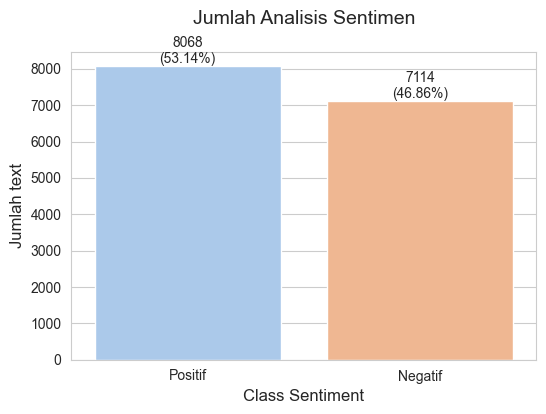

In [37]:
# Filter hanya Positif dan Negatif
df_filtered = df[df['sentiment'].isin(['Positif', 'Negatif'])]

# Hitung jumlah sentiment
sentiment_count = df_filtered['sentiment'].value_counts()

sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(6, 4))

ax = sns.barplot(
    x=sentiment_count.index,
    y=sentiment_count.values,
    palette='pastel'
)

plt.title('Jumlah Analisis Sentimen', fontsize=14, pad=20)
plt.xlabel('Class Sentiment', fontsize=12)
plt.ylabel('Jumlah text', fontsize=12)

total = len(df_filtered['sentiment'])

# Tambahkan jumlah dan persentase
for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    
    ax.text(
        i,
        count + 0.10,
        f'{count}\n({percentage})',
        ha='center',
        va='bottom'
    )

plt.show()

In [38]:
df.to_csv(os.path.join(RESULTS_PATH, "hasil_labelling.csv"), encoding='utf8', index=False)

In [39]:
df[['stemmed_text', 'sentiment']].sample(30)

,stemmed_text,sentiment
8885,upgrad log saldo ya,Positif
3476,aplikasi nih transfer cuman bank doang huu mua...,Negatif
13879,aplikasi anj tipu awas tipu promo aku ya cashb...,Negatif
10802,mohon maaf bayar spaylat ya terang suruh pinda...,Negatif
3323,transaksi salah pin ganti pin saldo ku hubungi...,Positif
9401,custom servic hormat akun buka bikin top pas t...,Positif
11541,coba tambah fitur cetak struk transaksi cetak ...,Positif
12925,bantu belanja promo,Positif
10887,top saldo masuk kali jam tunggu masuk,Negatif
13520,login upgrad tulis koneksi koneksi lancar kecewa,Negatif


## Preparation Data

In [41]:
# Hapus data yang tidak memiliki stemmed_text atau Sentiment
df_clean = df[['stemmed_text', 'sentiment']].dropna()
print(f"Data setelah cleaning: {len(df_clean)}")
print()

# Pisahkan fitur (X) dan target (y)
X = df_clean['stemmed_text']
y = df_clean['sentiment']

Data setelah cleaning: 15182



## Splitting Data

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% untuk testing
    random_state=SEED,  # Gunakan SEED yang sudah didefinisikan
    stratify=y          # Pastikan distribusi sentiment seimbang
)

print("Distribusi Sentiment di Training Set:")
print(y_train.value_counts())
print()

print("Distribusi Sentiment di Testing Set:")
print(y_test.value_counts())
print()

Distribusi Sentiment di Training Set:
sentiment
Positif    6454
Negatif    5691
Name: count, dtype: int64

Distribusi Sentiment di Testing Set:
sentiment
Positif    1614
Negatif    1423
Name: count, dtype: int64



## Data Transformation (TFIDF)

In [43]:
# Inisialisasi TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,      # Ambil 5000 kata paling penting
    min_df=2,               # Kata harus muncul minimal di 2 dokumen
    max_df=0.8,             # Kata tidak boleh muncul di >80% dokumen
    ngram_range=(1, 2),     # Unigram dan bigram
)

# Fit dan transform data training
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform data testing (JANGAN fit lagi!)
X_test_tfidf = tfidf.transform(X_test)

In [44]:
# Tampilkan 10 kata dengan TF-IDF tertinggi
feature_names = tfidf.get_feature_names_out()
print("Top 10 fitur TF-IDF:")
tfidf_scores = X_train_tfidf.sum(axis=0).A1
top_indices = tfidf_scores.argsort()[-10:][::-1]
for idx in top_indices:
    print(f"  - {feature_names[idx]}: {tfidf_scores[idx]:.2f}")


Top 10 fitur TF-IDF:
  - aplikasi: 548.85
  - ya: 361.32
  - isa: 291.06
  - saldo: 262.11
  - masuk: 242.92
  - bagu: 239.26
  - bantu: 228.89
  - mudah: 221.28
  - buka: 199.90
  - banget: 189.48


# Modeling

## Naive Bayes

### Baseline

In [45]:
# Inisialisasi model
base_nb = MultinomialNB(alpha=3.0, fit_prior=True)  # alpha = smoothing parameter

# Training
print("Training Naive Bayes...")
base_nb.fit(X_train_tfidf, y_train)

# Prediksi
y_pred_nb_base = base_nb.predict(X_test_tfidf)

Training Naive Bayes...


### Evaluate Baseline NB

In [46]:
# Evaluasi
nb_base_accuracy = accuracy_score(y_test, y_pred_nb_base)
nb_base_precision = precision_score(y_test, y_pred_nb_base, average='weighted', zero_division=0)
nb_base_recall = recall_score(y_test, y_pred_nb_base, average='weighted', zero_division=0)
nb_base_f1 = f1_score(y_test, y_pred_nb_base, average='weighted', zero_division=0)

print("Performa pada Test Set:")
print(f"  Accuracy:  {nb_base_accuracy:.4f} ({nb_base_accuracy*100:.2f}%)")
print(f"  Precision: {nb_base_precision:.4f} ({nb_base_precision*100:.2f}%)")
print(f"  Recall:    {nb_base_recall:.4f} ({nb_base_recall*100:.2f}%)")
print(f"  F1-Score:  {nb_base_f1:.4f} ({nb_base_f1*100:.2f}%)")
print()

Performa pada Test Set:
  Accuracy:  0.8153 (81.53%)
  Precision: 0.8156 (81.56%)
  Recall:    0.8153 (81.53%)
  F1-Score:  0.8148 (81.48%)



## Diagram Batang Performa Metode Naive Bayes

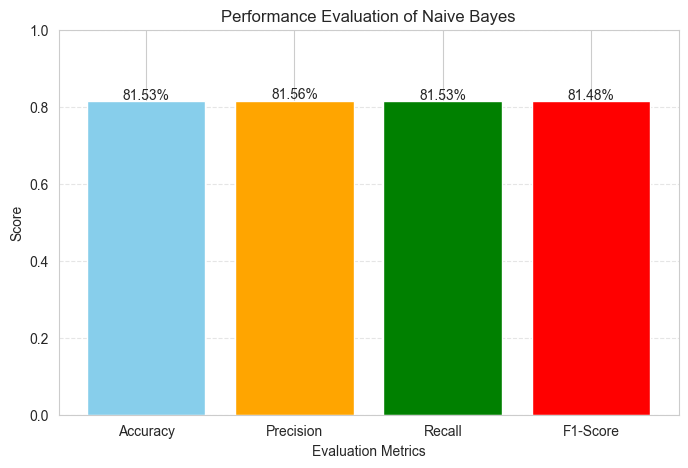

In [82]:
# Data metric
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
scores = [
    nb_base_accuracy,
    nb_base_precision,
    nb_base_recall,
    nb_base_f1
]

# Membuat diagram batang
plt.figure(figsize=(8,5))
bars = plt.bar(
    metrics,
    scores,
    color=['skyblue', 'orange', 'green', 'red']
)

# Menampilkan nilai di atas batang
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.005,
        f'{yval*100:.2f}%',
        ha='center'
    )

plt.ylim(0, 1)
plt.ylabel('Score')
plt.xlabel('Evaluation Metrics')
plt.title('Performance Evaluation of Naive Bayes')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Confusion Matrix Metode Naive Bayes

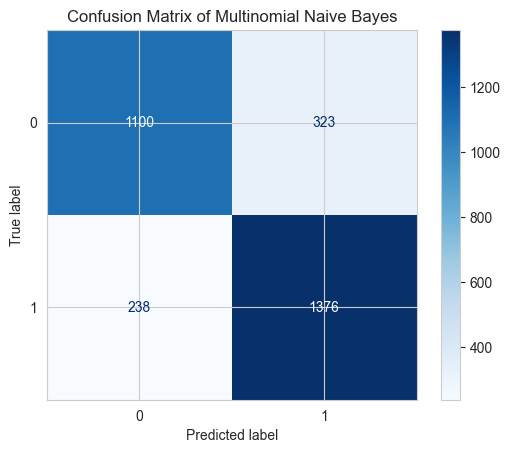

In [ ]:
cm = confusion_matrix(y_test, y_pred_nb_base)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title('Confusion Matrix of Multinomial Naive Bayes')
plt.show()

## SVM

### Baseline

In [75]:
# Inisialisasi model
base_svm = SVC(
    kernel='rbf',      # rbf kernel
    C=12.0,                # Regularization parameter
    random_state=SEED,
    probability=True,      # Enable probability estimates
    gamma='scale',
    class_weight='balanced'
)

# Training
print("Training SVM (ini mungkin memakan waktu)...")
base_svm.fit(X_train_tfidf, y_train)

# Prediksi
y_pred_svm_base = base_svm.predict(X_test_tfidf)

print("✅ SVM training selesai")

Training SVM (ini mungkin memakan waktu)...
✅ SVM training selesai


### Evaluate Baseline SVM

In [76]:
# Evaluasi
svm_base_accuracy = accuracy_score(y_test, y_pred_svm_base)
svm_base_precision = precision_score(y_test, y_pred_svm_base, average='weighted', zero_division=0)
svm_base_recall = recall_score(y_test, y_pred_svm_base, average='weighted', zero_division=0)
svm_base_f1 = f1_score(y_test, y_pred_svm_base, average='weighted', zero_division=0)

print("Performa pada Test Set:")
print(f"  Accuracy:  {svm_base_accuracy:.4f} ({svm_base_accuracy*100:.2f}%)")
print(f"  Precision: {svm_base_precision:.4f} ({svm_base_precision*100:.2f}%)")
print(f"  Recall:    {svm_base_recall:.4f} ({svm_base_recall*100:.2f}%)")
print(f"  F1-Score:  {svm_base_f1:.4f} ({svm_base_f1*100:.2f}%)")
print()

Performa pada Test Set:
  Accuracy:  0.8811 (88.11%)
  Precision: 0.8813 (88.13%)
  Recall:    0.8811 (88.11%)
  F1-Score:  0.8810 (88.10%)



## Diagram Batang Performa Metode SVM

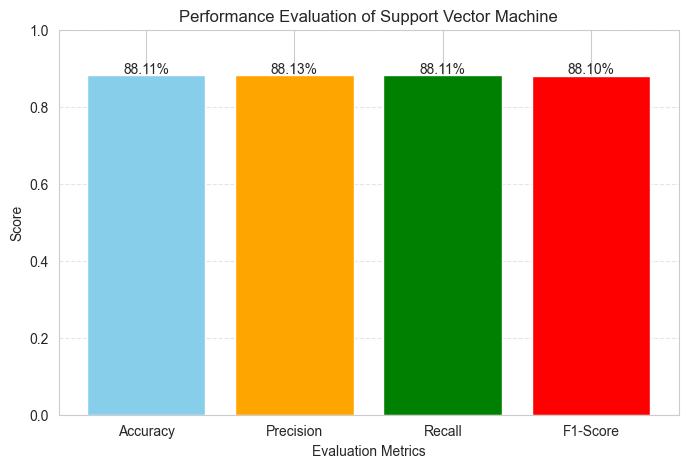

In [78]:
# Data metric
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
scores = [
    svm_base_accuracy,
    svm_base_precision,
    svm_base_recall,
    svm_base_f1
]

# Membuat diagram
plt.figure(figsize=(8,5))
bars = plt.bar(metrics, scores, color=['skyblue','orange','green','red'])

# Menampilkan nilai di atas batang
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.005,
        f'{yval*100:.2f}%',
        ha='center'
    )

plt.ylim(0, 1)
plt.ylabel('Score')
plt.xlabel('Evaluation Metrics')
plt.title('Performance Evaluation of Support Vector Machine')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Confusion Matrix Metode SVM

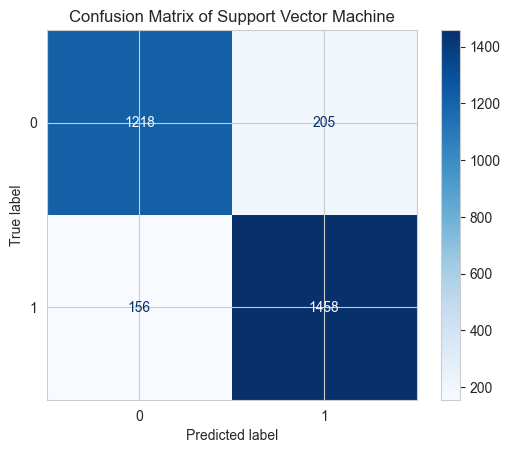

In [84]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm_base)

# Menampilkan
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title('Confusion Matrix of Support Vector Machine')
plt.show()

## Perbandingan Kinerja Metode Naive Bayes dan Support Vector Machine

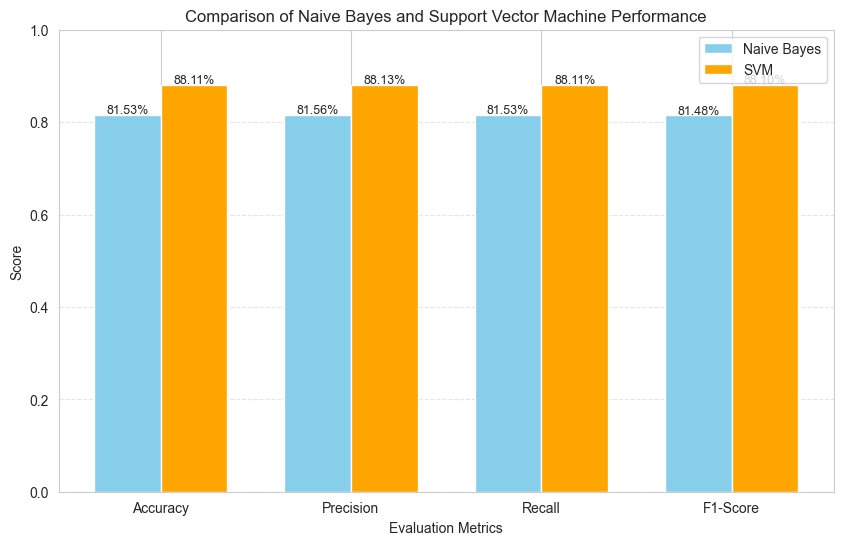

In [91]:
# Nama metrik
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Nilai Naive Bayes
nb_scores = [
    nb_base_accuracy,
    nb_base_precision,
    nb_base_recall,
    nb_base_f1
]

# Nilai SVM
svm_scores = [
    svm_base_accuracy,
    svm_base_precision,
    svm_base_recall,
    svm_base_f1
]

# Posisi batang
x = np.arange(len(metrics))
width = 0.35

# Membuat figure
plt.figure(figsize=(10,6))

# Batang Naive Bayes
bars1 = plt.bar(
    x - width/2,
    nb_scores,
    width,
    label='Naive Bayes',
    color='skyblue'
)

# Batang SVM
bars2 = plt.bar(
    x + width/2,
    svm_scores,
    width,
    label='SVM',
    color='orange'
)

# Menampilkan persentase pada masing-masing batang
for bar in bars1:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.003,
        f'{yval*100:.2f}%',
        ha='center',
        fontsize=9
    )

for bar in bars2:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.003,
        f'{yval*100:.2f}%',
        ha='center',
        fontsize=9
    )

# Pengaturan grafik
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.xlabel('Evaluation Metrics')
plt.title('Comparison of Naive Bayes and Support Vector Machine Performance')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# Inference

In [92]:
def predict_sentiment(text, model_name='nb'):
    """
    Fungsi untuk memprediksi sentiment dari teks baru
    
    Parameters:
    - text: teks review yang akan diprediksi
    - model_name: 'nb' untuk Naive Bayes, 'svm' untuk SVM
    
    Returns:
    - sentiment: hasil prediksi ('Positif' atau 'Negatif')
    - probability: probabilitas prediksi
    """
    # Pilih model
    if model_name.lower() == 'nb':
        model = base_nb
        model_display = "Naive Bayes"
    else:
        model = base_svm
        model_display = "SVM"
    
    # Preprocessing (sesuaikan dengan pipeline preprocessing kamu)
    # Untuk demo, kita asumsikan text sudah di-preprocess
    # Dalam praktik, kamu harus jalankan semua preprocessing steps
    
    # Transform ke TF-IDF
    text_tfidf = tfidf.transform([text])
    
    # Prediksi
    prediction = model.predict(text_tfidf)[0]
    
    # Probabilitas
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(text_tfidf)[0]
        confidence = max(proba)
    else:
        confidence = 1.0  # Naive Bayes tidak punya predict_proba by default
    
    print(f"Model: {model_display}")
    print(f"Teks: {text}")
    print(f"Prediksi: {prediction}")
    print(f"Confidence: {confidence:.2%}")
    print()
    
    return prediction, confidence


# Contoh penggunaan
test_texts = [
    "aplikasi bagus mudah digunakan",
    "lemot banget aplikasinya jelek",
    "saldo tidak masuk mohon diperbaiki",
    "sangat membantu transaksi cepat"
]

print("Prediksi dengan Naive Bayes:")
print("-" * 80)
for text in test_texts:
    predict_sentiment(text, model_name='nb')

print("\nPrediksi dengan SVM:")
print("-" * 80)
for text in test_texts:
    predict_sentiment(text, model_name='svm')

Prediksi dengan Naive Bayes:
--------------------------------------------------------------------------------
Model: Naive Bayes
Teks: aplikasi bagus mudah digunakan
Prediksi: Positif
Confidence: 63.17%

Model: Naive Bayes
Teks: lemot banget aplikasinya jelek
Prediksi: Negatif
Confidence: 71.31%

Model: Naive Bayes
Teks: saldo tidak masuk mohon diperbaiki
Prediksi: Positif
Confidence: 52.18%

Model: Naive Bayes
Teks: sangat membantu transaksi cepat
Prediksi: Positif
Confidence: 74.44%


Prediksi dengan SVM:
--------------------------------------------------------------------------------
Model: SVM
Teks: aplikasi bagus mudah digunakan
Prediksi: Negatif
Confidence: 63.03%

Model: SVM
Teks: lemot banget aplikasinya jelek
Prediksi: Negatif
Confidence: 94.06%

Model: SVM
Teks: saldo tidak masuk mohon diperbaiki
Prediksi: Negatif
Confidence: 77.57%

Model: SVM
Teks: sangat membantu transaksi cepat
Prediksi: Positif
Confidence: 95.02%



## Simpan semuanya

In [93]:
# Simpan model dan vectorizer
with open('naive_bayes_model.pkl', 'wb') as f:
    pickle.dump(base_nb, f)

with open('svm_model.pkl', 'wb') as f:
    pickle.dump(base_svm, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("✅ Model berhasil disimpan:")
print("   - naive_bayes_model.pkl")
print("   - svm_model.pkl")
print("   - tfidf_vectorizer.pkl")

✅ Model berhasil disimpan:
   - naive_bayes_model.pkl
   - svm_model.pkl
   - tfidf_vectorizer.pkl
